# Two new 0.7.0 families: copulas and gated mixtures

`mixle` 0.7.0 adds two distribution families that both express *dependence the classic building blocks
cannot*, and both compose into the same estimator machinery (`fit` / `optimize`, encoders,
`log_density`) as every other family:

* **`CopulaDistribution`** — Sklar's theorem as a first-class object: glue *arbitrary heterogeneous
  marginals* to a *dependence core* and fit the whole thing by inference-functions-for-margins (IFM).
* **`GatedMixtureDistribution`** — a mixture of experts whose mixing weights are a *learned function
  of a covariate* `p(k | z)`, not fixed constants.

Everything below runs on seeded synthetic data with known ground truth, so each claim is checkable.

## Part 1 — Copulas: arbitrary marginals, one dependence core

A copula separates *what each variable looks like on its own* (the marginals) from *how they move
together* (the dependence). That lets you pair a right-skewed `Gamma` marginal with a symmetric
`Gaussian` marginal and still model their correlation — something a joint Gaussian cannot do without
distorting the marginals.

We generate data with a known rank correlation pushed through two different marginals, then fit a
`CopulaDistribution` and check that IFM recovers both the dependence and each marginal's shape.

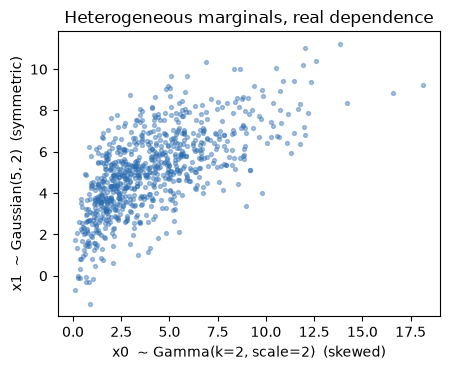

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma as spgamma, norm

import mixle.stats as st
from mixle.inference import optimize
from mixle.stats.combinator.copula import CopulaDistribution
from mixle.stats.multivariate.gaussian_copula import GaussianCopulaDistribution

def correlated_heterogeneous(seed, n=800, r=0.7):
    # a latent Gaussian dependence r, pushed through a Gamma(k=2, scale=2) and a Gaussian(5, 2) marginal
    rng = np.random.RandomState(seed)
    z = rng.multivariate_normal([0.0, 0.0], [[1.0, r], [r, 1.0]], size=n)
    u = norm.cdf(z)
    x0 = spgamma.ppf(u[:, 0], a=2.0, scale=2.0)     # skewed marginal
    x1 = norm.ppf(u[:, 1], loc=5.0, scale=2.0)       # symmetric marginal
    return list(zip(x0.tolist(), x1.tolist()))

data = correlated_heterogeneous(0, r=0.7)
xs = np.array(data)
fig, ax = plt.subplots(figsize=(4.6, 3.8))
ax.scatter(xs[:, 0], xs[:, 1], s=8, alpha=0.4, color='#2b6cb0')
ax.set_xlabel("x0  ~ Gamma(k=2, scale=2)  (skewed)")
ax.set_ylabel("x1  ~ Gaussian(5, 2)  (symmetric)")
ax.set_title("Heterogeneous marginals, real dependence")
plt.tight_layout(); plt.show()

Build the family as `CopulaDistribution([marginal_0, marginal_1], copula_core)` and fit by IFM. The
initial marginals and the identity-correlation core are deliberately wrong; IFM recovers them.

In [2]:
def proto():
    return CopulaDistribution(
        [st.GammaDistribution(1.0, 1.0), st.GaussianDistribution(0.0, 1.0)],   # wrong on purpose
        GaussianCopulaDistribution(np.eye(2)),                                  # independence, on purpose
    )

fit = optimize(data, proto().estimator(), prev_estimate=proto(), max_its=5, out=None)

print("recovered dependence  : corr = %.3f   (true 0.70)" % float(fit.copula.corr[0, 1]))
print("recovered marginal x0 : Gamma shape k = %.2f   (true 2.0)" % float(fit.marginals[0].k))
print("recovered marginal x1 : Gaussian mean = %.2f   (true 5.0)" % float(fit.marginals[1].mu))

recovered dependence  : corr = 0.701   (true 0.70)
recovered marginal x0 : Gamma shape k = 2.11   (true 2.0)
recovered marginal x1 : Gaussian mean = 5.03   (true 5.0)


Does the dependence actually earn its keep? Compare the fitted copula's log-likelihood against the
**independence** copula built from the *same* recovered marginals — so the only difference is whether
the model is allowed to use the correlation. The gap is the dependence, measured in nats.

In [3]:
def total_ll(dist, data):
    return float(np.sum(dist.seq_log_density(dist.dist_to_encoder().seq_encode(data))))

independent = CopulaDistribution(fit.marginals, GaussianCopulaDistribution(np.eye(2)))
ll_fit = total_ll(fit, data)
ll_indep = total_ll(independent, data)
print("log-likelihood  with dependence : %.1f" % ll_fit)
print("log-likelihood  independence    : %.1f" % ll_indep)
print("dependence is worth %.1f nats over %d points" % (ll_fit - ll_indep, len(data)))

log-likelihood  with dependence : -3217.4
log-likelihood  independence    : -3487.4
dependence is worth 270.1 nats over 800 points


## Part 2 — Gated mixtures: mixing weights that depend on a covariate

A plain mixture has fixed weights: `p(k)` is the same everywhere. A **gated** mixture makes the
weights a learned function of a covariate, `p(k | z)` — a mixture of experts. When the *regime*
depends on `z` (which expert generates `y`), the gate can route to the right expert per input, and a
fixed-weight mixture simply cannot express that.

We generate a switching process: the sign of `z` selects which of two experts (`N(-5,1)` vs `N(+5,1)`)
generates `y`. Then we fit a `GatedMixtureDistribution` and read out the learned routing.

In [4]:
from mixle.stats.latent.gated_mixture import GatedMixtureDistribution, SoftmaxGate

def switching_data(seed, n=1000):
    rng = np.random.RandomState(seed)
    z = rng.uniform(-3, 3, n)
    y = np.where(z < 0, rng.normal(-5, 1, n), rng.normal(5, 1, n))   # sign(z) picks the expert
    return list(zip(z.reshape(-1, 1).tolist(), y.tolist())), z, y

data, z, y = switching_data(0)

def gated_proto():
    return GatedMixtureDistribution(
        [st.GaussianDistribution(-1.0, 1.0), st.GaussianDistribution(1.0, 1.0)],
        SoftmaxGate.zeros(2, 1),          # gate over 2 experts from a 1-d covariate, initialized flat
    )

gated = optimize(data, gated_proto().estimator(), rng=np.random.RandomState(0), max_its=30, out=None)
means = sorted(c.mu for c in gated.components)
print("recovered experts : mu = %.2f, %.2f   (true -5.0, +5.0)" % (means[0], means[1]))

recovered experts : mu = -4.92, 4.98   (true -5.0, +5.0)


The gate is the new part: evaluate `p(k | z)` across the covariate range and you can see it hand
control from one expert to the other around `z = 0`, exactly where the generating regime switches.

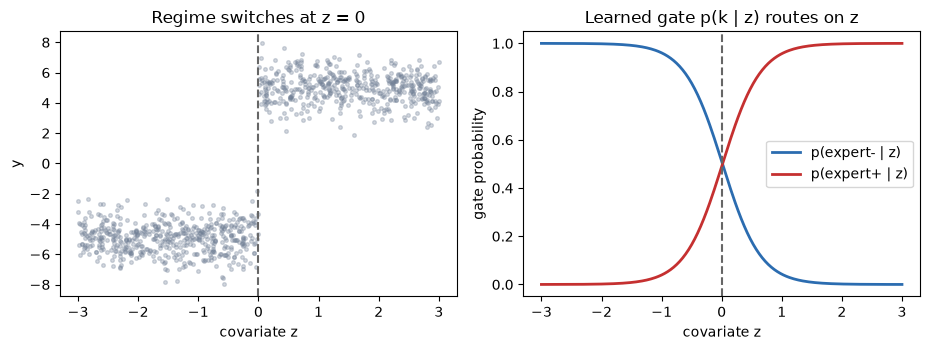

In [5]:
zs = np.linspace(-3, 3, 241).reshape(-1, 1)
gate_probs = np.exp(gated.gate.log_prob_batch(zs))     # (n, 2): p(expert k | z)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.4, 3.6))
ax0.scatter(z, y, s=7, alpha=0.3, color='#718096')
ax0.axvline(0, ls='--', c='0.4'); ax0.set_xlabel("covariate z"); ax0.set_ylabel("y")
ax0.set_title("Regime switches at z = 0")

ax1.plot(zs.ravel(), gate_probs[:, 0], lw=2, label='p(expert- | z)', color='#2b6cb0')
ax1.plot(zs.ravel(), gate_probs[:, 1], lw=2, label='p(expert+ | z)', color='#c53030')
ax1.axvline(0, ls='--', c='0.4'); ax1.set_xlabel("covariate z"); ax1.set_ylabel("gate probability")
ax1.set_title("Learned gate p(k | z) routes on z"); ax1.legend()
plt.tight_layout(); plt.show()

And the payoff: because the mixing genuinely depends on `z`, the gated mixture captures information a
plain fixed-weight mixture over `y` cannot. Fit both and compare log-likelihood.

In [6]:
ys = [row[1] for row in data]
plain = st.MixtureDistribution(
    [st.GaussianDistribution(-1.0, 1.0), st.GaussianDistribution(1.0, 1.0)], [0.5, 0.5]
)
plain_fit = optimize(ys, plain.estimator(), rng=np.random.RandomState(1), max_its=30, out=None)

ll_gated = total_ll(gated, data)
ll_plain = float(np.sum(plain_fit.seq_log_density(plain_fit.dist_to_encoder().seq_encode(ys))))
print("log-likelihood  gated (uses z) : %.1f" % ll_gated)
print("log-likelihood  plain mixture  : %.1f" % ll_plain)
print("the covariate-dependent gate is worth %.1f nats" % (ll_gated - ll_plain))

log-likelihood  gated (uses z) : -1483.6
log-likelihood  plain mixture  : -2091.8
the covariate-dependent gate is worth 608.2 nats


## What 0.7.0 gives you here

Two families that both express dependence the classic pieces cannot, both first-class citizens of the
same estimator API:

* **`CopulaDistribution`** decouples marginals from dependence (Sklar), fits heterogeneous marginals
  plus a dependence core by IFM, and quantifies exactly how many nats the dependence is worth.
* **`GatedMixtureDistribution`** turns a mixture into a mixture of experts with a **learned gate**
  `p(k | z)`, recovering a covariate-driven routing that a fixed-weight mixture cannot represent.

Because they lower to the ordinary `mixle` distribution/estimator contract, both drop straight into
records, mixtures, PPL slots, and everything else in the library.